In [1]:
using Pkg
Pkg.activate(".")

  Activating project at `~/Desktop/Waterloo/Masters/LOO_PIT_Manual/Capse_Planck`


In [2]:
# Pkg.add("Random")
# Pkg.add("LinearAlgebra")
# Pkg.add("Turing")
# Pkg.add("PosteriorStats")
# Pkg.add("Distributions")
# Pkg.add("PDMats")
# Pkg.add("LogExpFunctions")
# Pkg.add("Plots")
# Pkg.add("ArviZ")
# Pkg.add("HypothesisTests)

In [3]:
using Random
using LinearAlgebra
using Turing
using PosteriorStats
using Distributions
using PDMats
using LogExpFunctions
using Plots
using ArviZ
using HypothesisTests

### Model Set Up

In [4]:
# Define the Turing model
@model function myfoo(SL, x)
    a ~ Uniform(-10, 10)
    b ~ Uniform(-10, 10)
    μ = a .* x .+ b
    S = Symmetric(SL * SL')
    # Multivariate Normal observation
    y ~ MvNormal(μ, PDMat(Cholesky(SL)))
    return y
end

# Setup synthetic data
Random.seed!(1234)
n = 250
R = rand(LKJCholesky(n, 1))
s = rand(filldist(truncated(TDist(7); lower=0), n))
SL = LowerTriangular(Diagonal(s) * R.L) + 0.2I
S = Symmetric(SL * SL')

x = Array(LinRange(-7, 7, n))
a_true = 1.0
b_true = -3.0
y = rand(MvNormal(a_true .* x .+ b_true, S))

250-element Vector{Float64}:
  -9.306347140590663
 -10.102758836642797
  -8.886500992353275
 -11.073620474746376
  -9.775510862035619
  -9.505898721668018
  -9.923104962207496
  -9.32218746525733
  -9.88456956971678
  -9.716277617065318
 -10.095524229681896
  -8.15496908942246
  -8.352331350072456
   ⋮
   1.2181365971786131
   2.9839573103288557
   3.6630942503756034
   0.44410834484482153
   3.3718790395156732
   2.922326089286279
   2.992031408612971
   1.962043056603038
   3.230532804887518
   1.2480455454717356
   5.163927510311826
   2.9777567932436124

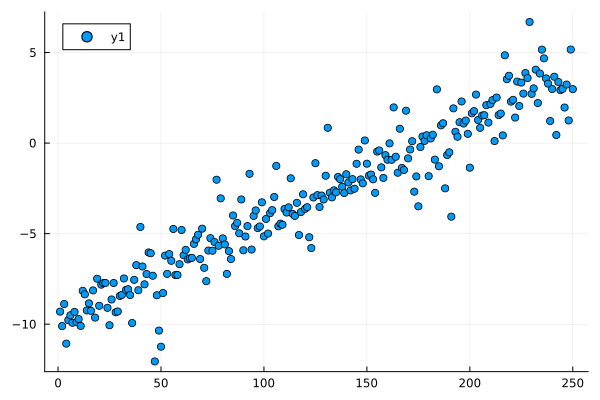

In [5]:
scatter(y)

### Running Chains

In [6]:
num_steps = 5000
num_chains = 8

# Sample from the model using 8 parallel chains
chns = sample(myfoo(SL, x) | (; y), NUTS(), MCMCThreads(), num_steps, num_chains)

# Generate posterior predictions: stochastic realizations from the likelihood
y_pred = predict(myfoo(SL, x), chns)

┌ Info: Found initial step size
└   ϵ = 0.0015625
┌ Info: Found initial step size
└   ϵ = 0.0015625
┌ Info: Found initial step size
└   ϵ = 0.0015625
┌ Info: Found initial step size
└   ϵ = 0.00078125
Sampling (4 threads):  46%|█████████████▎               |  ETA: 0:01:38┌ Info: Found initial step size
└   ϵ = 0.00078125
Sampling (4 threads):  48%|█████████████▉               |  ETA: 0:01:33┌ Info: Found initial step size
└   ϵ = 0.00078125
┌ Info: Found initial step size
└   ϵ = 0.00078125
┌ Info: Found initial step size
└   ϵ = 0.0015625
Sampling (4 threads): 100%|█████████████████████████████| Time: 0:03:05


Chains MCMC chain (5000×250×8 Array{Float64, 3}):

Iterations        = 1:1:5000
Number of chains  = 8
Samples per chain = 5000
parameters        = y[1], y[2], y[3], y[4], y[5], y[6], y[7], y[8], y[9], y[10], y[11], y[12], y[13], y[14], y[15], y[16], y[17], y[18], y[19], y[20], y[21], y[22], y[23], y[24], y[25], y[26], y[27], y[28], y[29], y[30], y[31], y[32], y[33], y[34], y[35], y[36], y[37], y[38], y[39], y[40], y[41], y[42], y[43], y[44], y[45], y[46], y[47], y[48], y[49], y[50], y[51], y[52], y[53], y[54], y[55], y[56], y[57], y[58], y[59], y[60], y[61], y[62], y[63], y[64], y[65], y[66], y[67], y[68], y[69], y[70], y[71], y[72], y[73], y[74], y[75], y[76], y[77], y[78], y[79], y[80], y[81], y[82], y[83], y[84], y[85], y[86], y[87], y[88], y[89], y[90], y[91], y[92], y[93], y[94], y[95], y[96], y[97], y[98], y[99], y[100], y[101], y[102], y[103], y[104], y[105], y[106], y[107], y[108], y[109], y[110], y[111], y[112], y[113], y[114], y[115], y[116], y[117], y[118], y[119], y[120], y

### Marco's Manual LOO-PIT

In [7]:
# Extract parameter samples
a_samples = chns[:a].data
b_samples = chns[:b].data

# Compute the mean array for all draws and chains (draws, chains, n)
μ_array = a_samples .* reshape(x, 1, 1, n) .+ b_samples

S_pd = PDMat(Cholesky(SL))

250×250 PDMat{Float64, Matrix{Float64}}:
  0.306031      0.000524969   0.0214048    …  -0.00201739  -0.0405174
  0.000524969   0.30238      -0.0199308       -0.0248133    0.0611419
  0.0214048    -0.0199308     0.774413         0.0069836   -0.0886018
  0.00792558   -0.040338     -0.0789993        0.0320866   -0.0202541
  0.00631835    0.00231243   -0.024014        -0.00446768   0.0536257
 -0.000695269  -0.000603941  -0.000319996  …  -0.00251502  -0.0300127
  0.0037331    -0.0385822    -0.0345929        0.0207845    0.0612133
  0.00163932    0.000293194   0.00190496       0.00814882   0.00720814
  0.0444832    -0.0509096     0.0367891        0.0346404   -0.0789475
  0.0195966     0.00233195   -0.0195871        0.0274618    0.0391452
  0.00754799   -0.0118603     0.0273662    …  -0.00457955  -0.277901
  0.0326152    -0.00148078    0.0470691       -0.0240015    0.156082
 -0.0192092     0.00974992    0.0682418        0.0417487    0.128266
  ⋮                                        ⋱       

### Log-Likelihoods

In [8]:
# Instantiate distributions for each posterior slice
dists = map(μ -> MvNormal(μ, S_pd), eachslice(μ_array; dims=(1, 2)))

# Calculate pointwise conditional log-likelihoods
log_like = PosteriorStats.pointwise_conditional_loglikelihoods(y, dists)

5000×8×250 Array{Float64, 3}:
[:, :, 1] =
  0.472249   0.498472  0.421996  0.423268  …  0.110703  0.506095  0.503033
  0.489474   0.382285  0.489556  0.437092     0.288161  0.430325  0.518589
  0.516382   0.419368  0.494424  0.434472     0.534324  0.31524   0.420768
  0.237366   0.49295   0.462889  0.54134      0.541642  0.467848  0.432174
  0.523315   0.409335  0.488662  0.541008     0.482363  0.505665  0.52625
  0.517554   0.411199  0.418314  0.483678  …  0.526233  0.396286  0.332485
  0.476338   0.539868  0.498477  0.509142     0.316174  0.425359  0.360632
  0.495533   0.275911  0.503801  0.481568     0.272043  0.445973  0.439127
  0.499653   0.423932  0.519006  0.488175     0.282613  0.536672  0.494167
  0.535803   0.472788  0.468531  0.350246     0.224738  0.542621  0.455499
  0.453656   0.349344  0.469065  0.528841  …  0.429846  0.541197  0.473831
  0.362522   0.35505   0.511418  0.533526     0.53984   0.382968  0.469
  0.504692   0.335046  0.487596  0.484956     0.539887  0.4048

### PSIS (Pareto Smoothed Importance Sampling)

In [9]:
# Compute LOO to obtain smoothed importance weights
loo_res = loo(log_like)
log_weights = loo_res.psis_result.log_weights

5000×8×250 Array{Float64, 3}:
[:, :, 1] =
 -10.6388  -10.665   -10.5885  -10.5898  …  -10.2815  -10.6726  -10.6696
 -10.656   -10.5488  -10.6561  -10.6036     -10.4547  -10.5969  -10.6851
 -10.6829  -10.5859  -10.661   -10.601      -10.7009  -10.4818  -10.5873
 -10.4039  -10.6595  -10.6294  -10.7079     -10.7082  -10.6344  -10.5987
 -10.6898  -10.5759  -10.6552  -10.7075     -10.6489  -10.6722  -10.6928
 -10.6841  -10.5777  -10.5848  -10.6502  …  -10.6928  -10.5628  -10.499
 -10.6429  -10.7064  -10.665   -10.6757     -10.4827  -10.5919  -10.5272
 -10.6621  -10.4424  -10.6703  -10.6481     -10.4386  -10.6125  -10.6057
 -10.6662  -10.5905  -10.6855  -10.6547     -10.4491  -10.7032  -10.6607
 -10.7023  -10.6393  -10.6351  -10.5168     -10.3913  -10.7092  -10.622
 -10.6202  -10.5159  -10.6356  -10.6954  …  -10.5964  -10.7077  -10.6404
 -10.5291  -10.5216  -10.6779  -10.7001     -10.7064  -10.5495  -10.6355
 -10.6712  -10.5016  -10.6541  -10.6515     -10.7064  -10.5714  -10.6145
   ⋮       

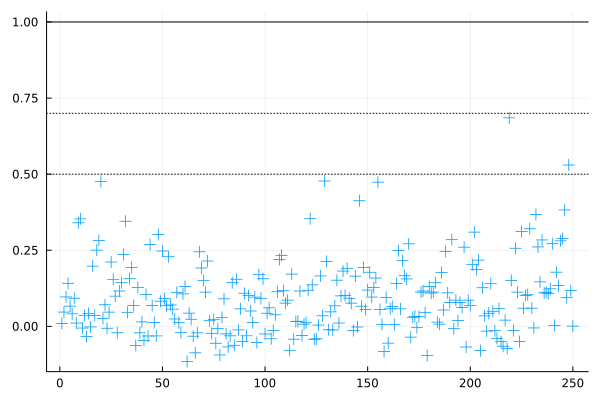

In [10]:
scatter(loo_res.pointwise.pareto_shape; marker=:+, markersize = 6, legend=false, linewidth=2)
hline!([0.5, 0.7], linestyle=:dot, color=:black)
hline!([1.0], linestyle=:solid, color=:black)

### PIT (Probability Integral Transform)

In [11]:
# Clean predictions into (draws, chains, n)
y_pred_array = permutedims(y_pred[[Symbol("y[$i]") for i in 1:n]].value.data, (1, 3, 2))

pitvals_manual = zeros(n)
for i in 1:n
    y_pred_i = y_pred_array[:, :, i] 
    log_w_i = log_weights[:, :, i]
    
    # Identify which draws fall below the observation
    mask = y_pred_i .<= y[i]
    
    # Estimate the CDF as the sum of the weights of those draws
    pitvals_manual[i] = any(mask) ? exp(logsumexp(log_w_i[mask])) : 0.0
end

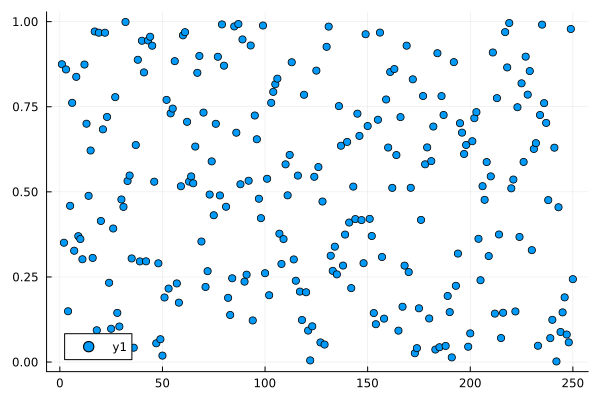

In [12]:
scatter(pitvals_manual)

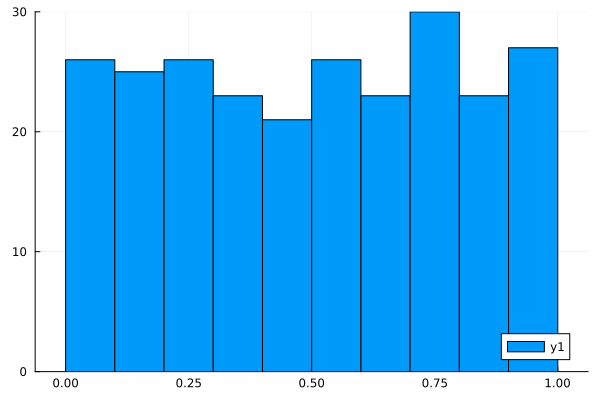

In [13]:
histogram(pitvals_manual, bins=10)

### Comparison of first data point observation and draws

In [14]:
y_pred_array

5000×8×250 Array{Float64, 3}:
[:, :, 1] =
  -9.6866    -9.90394   -9.20801  …  -10.1198   -10.0166   -10.3895
 -10.272     -9.44462   -9.19248      -9.81771   -9.72922   -9.58902
  -9.39778  -11.3485    -9.55406     -10.1939   -10.4731    -9.99529
  -9.6205    -9.94807   -9.00149     -10.0719   -10.0151   -10.2968
 -11.1013    -9.54916   -9.98194     -10.2763    -9.5408    -9.98952
  -9.59179  -10.8463   -10.34     …   -9.47335   -8.7752    -9.44675
 -10.0308    -9.66735   -9.99302      -9.12862   -9.36309  -10.3757
  -9.36175  -10.551     -8.99559      -9.24887   -9.44522  -11.0007
  -9.37058   -9.51872   -9.78029      -9.85138   -9.6605    -9.75147
  -9.72982  -10.3819    -8.99041     -10.3801   -10.4587   -10.8588
  -9.67256  -10.0781    -9.79494  …   -9.96826  -10.5902   -10.1131
  -9.95804   -9.19607   -9.90839     -10.4704    -9.61961  -10.397
 -10.3472   -10.4458   -10.1778       -9.42771   -9.2016    -9.478
   ⋮                              ⋱    ⋮                   
  -9.11052 

In [15]:
y_1_array = []
for i in 1:num_chains
    y_1_array = append!(y_1_array, y_pred_array[:,i,1])
end

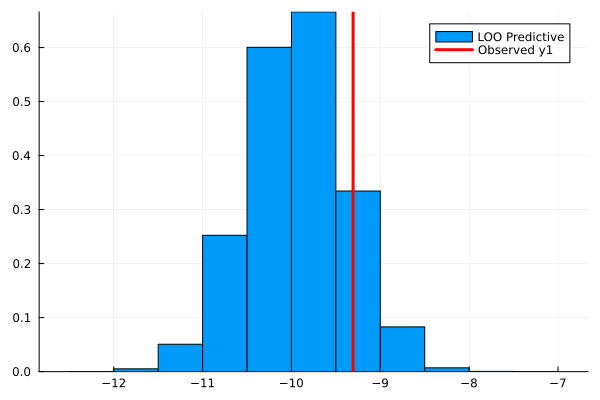

In [16]:
histogram(y_1_array, normalize=:pdf, bins = 20, label="LOO Predictive")
vline!([y[1]], color=:red, linewidth=3, label = "Observed y1")

### Comparison of Manual Approaches

In [17]:
# println("Marco Manual LOO-PIT (first 5): ", round.(pitvals_manual[1:5], digits=4))
# println("Ethan Manual LOO-PIT (first 5): ", round.(PIT_Values[1:5], digits=4))

In [18]:
# scatter(PIT_Values, pitvals_manual)
# plot!([0.0, 0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1.0],[0.0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1.0])

In [19]:
# # Perform the KS test for the Monte Carlo version
ks_test_marco = ExactOneSampleKSTest(pitvals_manual, Uniform(0, 1))

# # Perform the KS test for the Exact Analytic version
# ks_test_ethan = ExactOneSampleKSTest(PIT_Values, Uniform(0, 1))

println("Marco LOO-PIT KS test p-value:    ", pvalue(ks_test_marco))
# println("Ethan LOO-PIT KS test p-value: ", pvalue(ks_test_ethan))

Marco LOO-PIT KS test p-value:    0.9758230416592752
